In [1]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
#Constantes físicas
h = 6.62607015e-34 #Constante de Planck (J·s)
c = 2.99792458e8 #Velocidad de la luz (m/s)
k_B = 1.380649e-23 #Constante de Boltzmann (J/K)

Crear un espectro

In [4]:
def spectrum_generator(lambda_data, T, lambda_absor, depth, gamma, z):
    B_data = ((2*h*c**2)/(lambda_data**5)) / (np.exp((h*c)/(lambda_data*k_B*T))-1)
    B_data_abs = B_data * (1 - (depth*gamma**2 / ((lambda_data - lambda_absor)**2 + gamma**2)))
    noise = np.random.normal(0,10**12,len(B_data_abs))
    lambda_data_shifted = lambda_data*(1+z)
    return lambda_data_shifted, B_data_abs + noise

In [41]:
#Parámetros
T = 10000 #Temperatura
z = 0.66 #Redshift

#Parámetros de la línea Hα
lambda_Halpha = 656.28e-9  #656.28 nm en metros
depth = 0.7 #Profundidad de absorción (entre 0 y 1)
gamma = 1e-9 #ancho Lorentziano

#Dominio de Longitud de Onda (en nm)
lambda_0 = 100
lambda_f = 3000
N_lambda = 2500

lambda_data = np.linspace(lambda_0, lambda_f, N_lambda) * 1e-9 #lo paso a metros

In [43]:
lambdaDom, BRang = spectrum_generator(lambda_data, T, lambda_Halpha, depth, gamma, z)

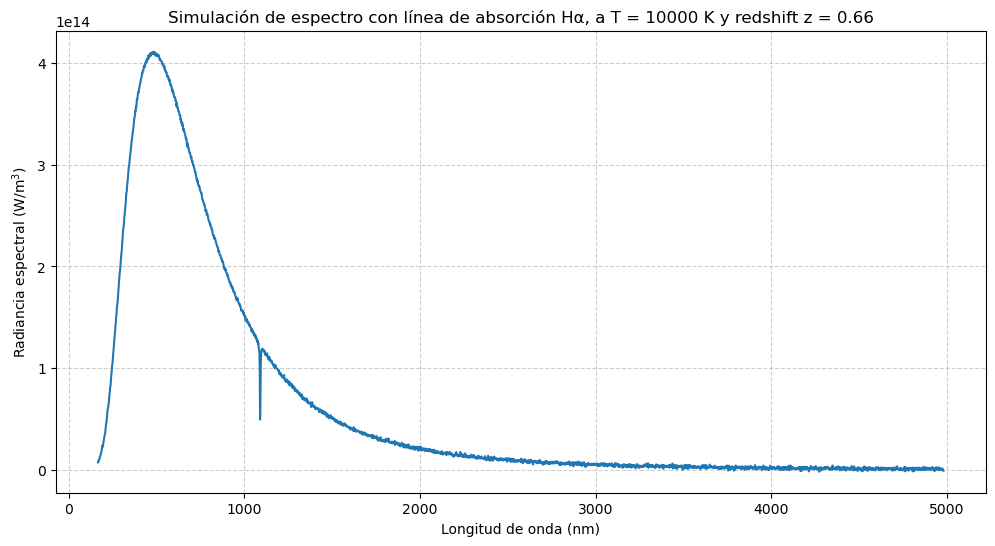

In [45]:
# Graficar
plt.figure(figsize=(12, 6))
plt.plot(lambdaDom * 1e9, BRang)
plt.title(f'Simulación de espectro con línea de absorción Hα, a T = {T} K y redshift z = {z}')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.xlim(400, 1000)
plt.show()

Crear varios espectros con T y z random 

In [9]:
#Número de espectros a generar
N_spectra0 = 5           

#Rango de parámetros aleatorios
np.random.seed(42)
T_values0 = np.random.uniform(3000, 15000, N_spectra0)
z_values0 = np.random.uniform(0, 1, N_spectra0)

In [10]:
def spectra_generator(N_spectra, T_values, z_values):
    for i in range(N_spectra):
        T = T_values[i]
        z = z_values[i]
        yield spectrum_generator(lambda_data, T, lambda_Halpha, depth, gamma, z)

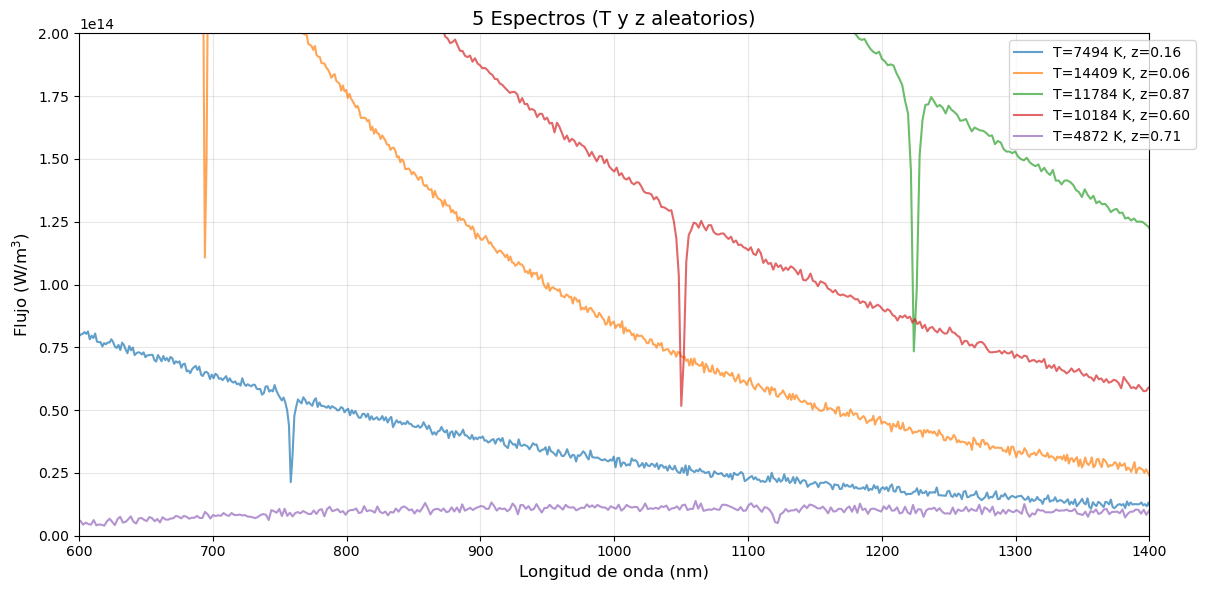

In [11]:
plt.figure(figsize=(12, 6))
plt.title('5 Espectros (T y z aleatorios)', fontsize=14)
plt.xlabel('Longitud de onda (nm)', fontsize=12)
plt.ylabel('Flujo (W/m$^3$)', fontsize=12)
plt.grid(alpha=0.3)

for i, (lambda_shifted, spectrum) in enumerate(spectra_generator(N_spectra0, T_values0, z_values0)):
    plt.plot(lambda_shifted * 1e9, spectrum, alpha=0.7, label=f'T={T_values0[i]:.0f} K, z={z_values0[i]:.2f}')

plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.xlim(600,1400)
plt.ylim(0,0.2e15)
plt.show()

Guardar datos

In [13]:
N_spectra = 5000
# Generar todos los datos primero (para evitar regenerarlos)

T_values = np.random.uniform(3000, 15000, N_spectra)
z_values = np.random.uniform(0, 1, N_spectra)

all_lambda = []
all_spectra = []
for lambda_shifted, spectrum in spectra_generator(N_spectra, T_values, z_values):
    all_lambda.append(lambda_shifted)
    all_spectra.append(spectrum)

# Guardar en HDF5
with h5py.File('espectros.h5', 'w') as f:
    f.create_dataset('lambda', data=np.array(all_lambda))
    f.create_dataset('spectra', data=np.array(all_spectra))
    f.create_dataset('T', data=T_values)
    f.create_dataset('z', data=z_values)
    f.attrs['description'] = 'Espectros estelares sintéticos con líneas H-alpha'

In [14]:
#Cargar datos
with h5py.File('espectros.h5', 'r') as f:
    spectra = f['spectra'][:]
    lambda_shifted = f['lambda'][:]
    T = f['T'][:]
    z = f['z'][:]

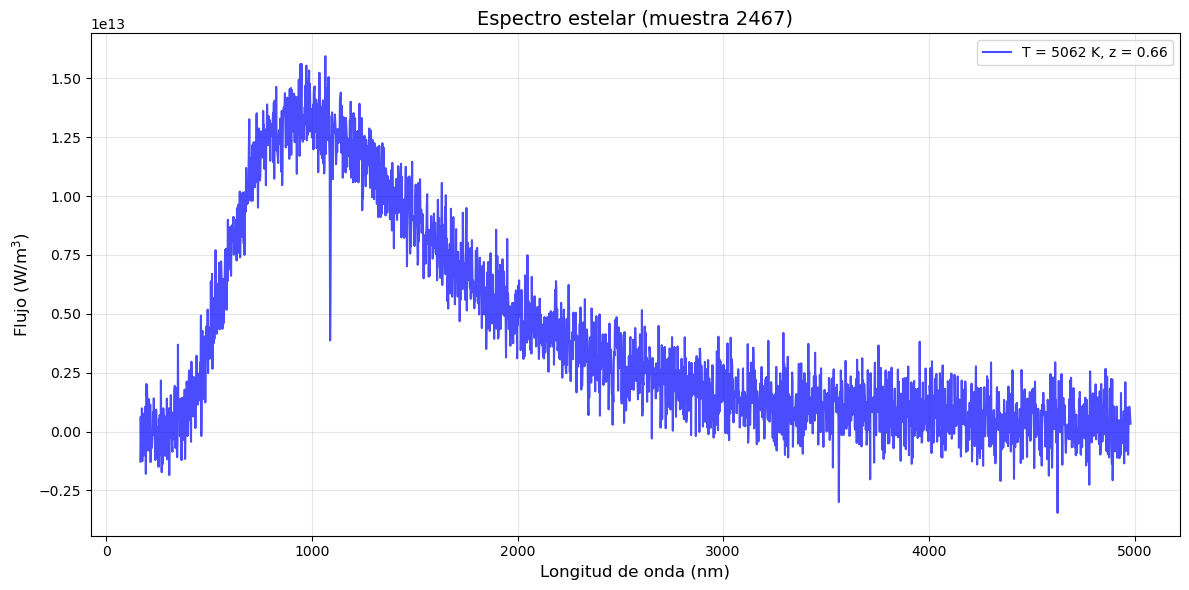

In [31]:
# Elegir un espectro aleatorio
idx = np.random.randint(0, len(spectra))  # Índice aleatorio
lambda_single = lambda_shifted[idx]       # Longitudes de onda para el espectro idx
spectrum_single = spectra[idx]            # Flujo del espectro idx
T_single = T[idx]                         # Temperatura del espectro idx
z_single = z[idx]                         # Corrimiento al rojo del espectro idx

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(lambda_single * 1e9, spectrum_single, 'b-', alpha=0.7, 
         label=f'T = {T_single:.0f} K, z = {z_single:.2f}')
plt.title(f'Espectro estelar (muestra {idx})', fontsize=14)
plt.xlabel('Longitud de onda (nm)', fontsize=12)
plt.ylabel('Flujo (W/m$^3$)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
# plt.xlim(600, 1400)  # Rango de interés (H-alpha está en ~656 nm)
plt.tight_layout()
plt.show()